# Sample code for visualization of CPD validation

This is just to give you an idea of what I had in mind.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import numpy.random as rnd
import string

In [2]:
sns.set_context("talk")
sns.set_style("ticks")

In [3]:
# aa position
x = np.arange(-10, 11, 1)
#ccc= np.array([-10,  -9,  -8,  -7,  -6])
x

array([-10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,
         3,   4,   5,   6,   7,   8,   9,  10])

In [4]:
def random_data():
    """
    Generate a random data set where:
    9 = CPD site
    2 = match
    1 = mismatch
    0 = gap
    """
    y = rnd.binomial(n=2, p=.9, size=21)
    y[10] = 9
    return y
random_data()

array([2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 9, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [5]:
def get_score(data):
    """
    Score the data using the following criteria:
    
    * match: add 5 points
    * gap: subtract 5 points

    Parameters
    ----------
    data : array
        Classification of +/- 10 aa surrounding a CPD. 

    Returns
    -------
    int
        Score.
    """    
    score = 0
    for i in range(21):
        if data[i]==2:
            score += 5
        elif y[i]==0:
            score += -5
    return score

In [6]:
letters = string.ascii_uppercase
def random_name():
    '''Generate a random gene name.'''
    return ''.join(rnd.choice(list(letters), 3)) + str(rnd.randint(1, 20))
random_name()

'WNN10'

In [7]:
random_data()

array([1, 2, 2, 2, 2, 2, 2, 2, 1, 2, 9, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2])

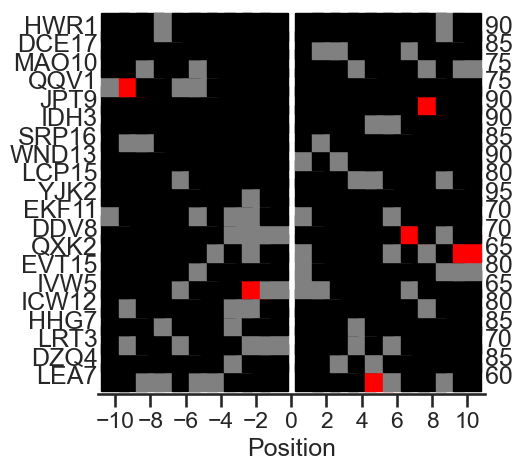

In [8]:
# sample data where matches are 1, mismatches are 0, and gaps are -1; the CPD site gets a 9 for clarity
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
for j in range(20):
    y = random_data()
    for i in range(21):
        if x[i]!=0:
            if y[i]==2:
                ax.plot(x[i], [j], 'ks', ms=20)
            elif y[i]==1:
                ax.plot(x[i], [j], 's', color="0.5", ms=20)
            elif y[i]==0:
                ax.plot(x[i], [j], 'rs', ms=20)
    ax.text(-11, j, random_name(), ha='right', va='center')
    ax.text(11, j, str(get_score(y)), ha='left', va='center')
ax.get_yaxis().set_visible(False)
sns.despine(left=True)
ax.set_xticks(np.arange(-10, 11, 2))
ax.set_xlabel('Position')
fig.savefig('validation_viz.pdf')

In [ ]:
!open validation_viz.pdf

#### Let's apply this to our data

In [ ]:
import pandas as pd
import os
os.chdir("Outputs_primates")
os.getcwd()

'/Users/adesinamary/Documents/kondrashov/Outputs_primates'

In [16]:
import numpy as np
np.nan

nan

In [14]:
flanking_df= pd.read_csv("AllGenes_flanking_df.csv")
flanking_scores = pd.read_csv("AllGenes_flanking_scores.csv")

In [15]:
def encode_status(row):
    if row["relative_position"] == 0:
        return 9

    status = str(row["status"]).lower()

    if status == "match":
        return 1
    elif status == "different":
        return 0
    elif status == "gap":
        return -1

    return np.nan

In [21]:
flanking_df["plot_value"] = flanking_df.apply(encode_status, axis= 1)
flanking_df.head()

,gene,human_protein,site,mut,species,species_protein,relative_position,human_aa,species_aa,status,plot_value
0,ACADM,NP_000007.1,29,L,Aotus nancymaae,NP_001125020.1,-10,H,H,match,1.0
1,ACADM,NP_000007.1,29,L,Aotus nancymaae,NP_001125020.1,-9,W,W,match,1.0
2,ACADM,NP_000007.1,29,L,Aotus nancymaae,NP_001125020.1,-8,R,R,match,1.0
3,ACADM,NP_000007.1,29,L,Aotus nancymaae,NP_001125020.1,-7,S,S,match,1.0
4,ACADM,NP_000007.1,29,L,Aotus nancymaae,NP_001125020.1,-6,Q,Q,match,1.0


In [ ]:
# I'll create an identifier for each CPD
flanking_df["identifier"] = (flanking_df["gene"].astype(str) 
                             + ":"
                             + flanking_df["site"].astype(str)
                             + "|"
                             + flanking_df["species"].astype(str)
                             )

In [32]:
flanking_df.head(20)

,gene,human_protein,site,mut,species,species_protein,relative_position,human_aa,species_aa,status,plot_value,identifier
0,ACADM,NP_000007.1,29,L,Aotus nancymaae,NP_001125020.1,-10,H,H,match,1.0,ACADM:29|Aotus nancymaae
1,ACADM,NP_000007.1,29,L,Aotus nancymaae,NP_001125020.1,-9,W,W,match,1.0,ACADM:29|Aotus nancymaae
2,ACADM,NP_000007.1,29,L,Aotus nancymaae,NP_001125020.1,-8,R,R,match,1.0,ACADM:29|Aotus nancymaae
3,ACADM,NP_000007.1,29,L,Aotus nancymaae,NP_001125020.1,-7,S,S,match,1.0,ACADM:29|Aotus nancymaae
4,ACADM,NP_000007.1,29,L,Aotus nancymaae,NP_001125020.1,-6,Q,Q,match,1.0,ACADM:29|Aotus nancymaae
5,ACADM,NP_000007.1,29,L,Aotus nancymaae,NP_001125020.1,-5,H,H,match,1.0,ACADM:29|Aotus nancymaae
6,ACADM,NP_000007.1,29,L,Aotus nancymaae,NP_001125020.1,-4,T,T,match,1.0,ACADM:29|Aotus nancymaae
7,ACADM,NP_000007.1,29,L,Aotus nancymaae,NP_001125020.1,-3,K,K,match,1.0,ACADM:29|Aotus nancymaae
8,ACADM,NP_000007.1,29,L,Aotus nancymaae,NP_001125020.1,-2,A,S,different,0.0,ACADM:29|Aotus nancymaae
9,ACADM,NP_000007.1,29,L,Aotus nancymaae,NP_001125020.1,-1,N,A,different,0.0,ACADM:29|Aotus nancymaae


In [36]:
rows = flanking_df["identifier"].unique()
rows
#enumerate(rows)

<StringArray>
[           'ACADM:29|Aotus nancymaae',        'ACADM:29|Saimiri boliviensis',
         'ACADM:29|Callithrix jacchus',             'ACADM:29|Sapajus apella',
         'ACADM:31|Otolemur garnettii',         'ACADM:31|Nycticebus coucang',
               'ACADM:103|Lemur catta',           'ACADM:29|Hylobates moloch',
    'ACADVL:174|Propithecus coquereli', 'ACADVL:219|Symphalangus syndactylus',
 ...
  'WT1:341|Macaca thibetana thibetana',   'WT1:341|Piliocolobus tephrosceles',
           'WT1:341|Macaca nemestrina',                'WT1:341|Pongo abelii',
         'WT1:341|Nomascus leucogenys',     'WT1:341|Gorilla gorilla gorilla',
    'WT1:341|Symphalangus syndactylus',           'WT1:341|Eulemur rufifrons',
            'WT1:341|Hylobates moloch',              'ZEB2:1049|Pongo abelii']
Length: 241, dtype: str

In [31]:
for i, cpd in enumerate(rows):
    subset = flanking_df[flanking_df["identifier"] == cpd]
print(subset)

      gene human_protein  site mut       species species_protein  \
5103  ZEB2   NP_000007.1  1049   R  Pongo abelii  NP_001125020.1   
5104  ZEB2   NP_000007.1  1049   R  Pongo abelii  NP_001125020.1   
5105  ZEB2   NP_000007.1  1049   R  Pongo abelii  NP_001125020.1   
5106  ZEB2   NP_000007.1  1049   R  Pongo abelii  NP_001125020.1   
5107  ZEB2   NP_000007.1  1049   R  Pongo abelii  NP_001125020.1   
5108  ZEB2   NP_000007.1  1049   R  Pongo abelii  NP_001125020.1   
5109  ZEB2   NP_000007.1  1049   R  Pongo abelii  NP_001125020.1   
5110  ZEB2   NP_000007.1  1049   R  Pongo abelii  NP_001125020.1   
5111  ZEB2   NP_000007.1  1049   R  Pongo abelii  NP_001125020.1   
5112  ZEB2   NP_000007.1  1049   R  Pongo abelii  NP_001125020.1   
5113  ZEB2   NP_000007.1  1049   R  Pongo abelii  NP_001125020.1   
5114  ZEB2   NP_000007.1  1049   R  Pongo abelii  NP_001125020.1   
5115  ZEB2   NP_000007.1  1049   R  Pongo abelii  NP_001125020.1   
5116  ZEB2   NP_000007.1  1049   R  Pongo abelii

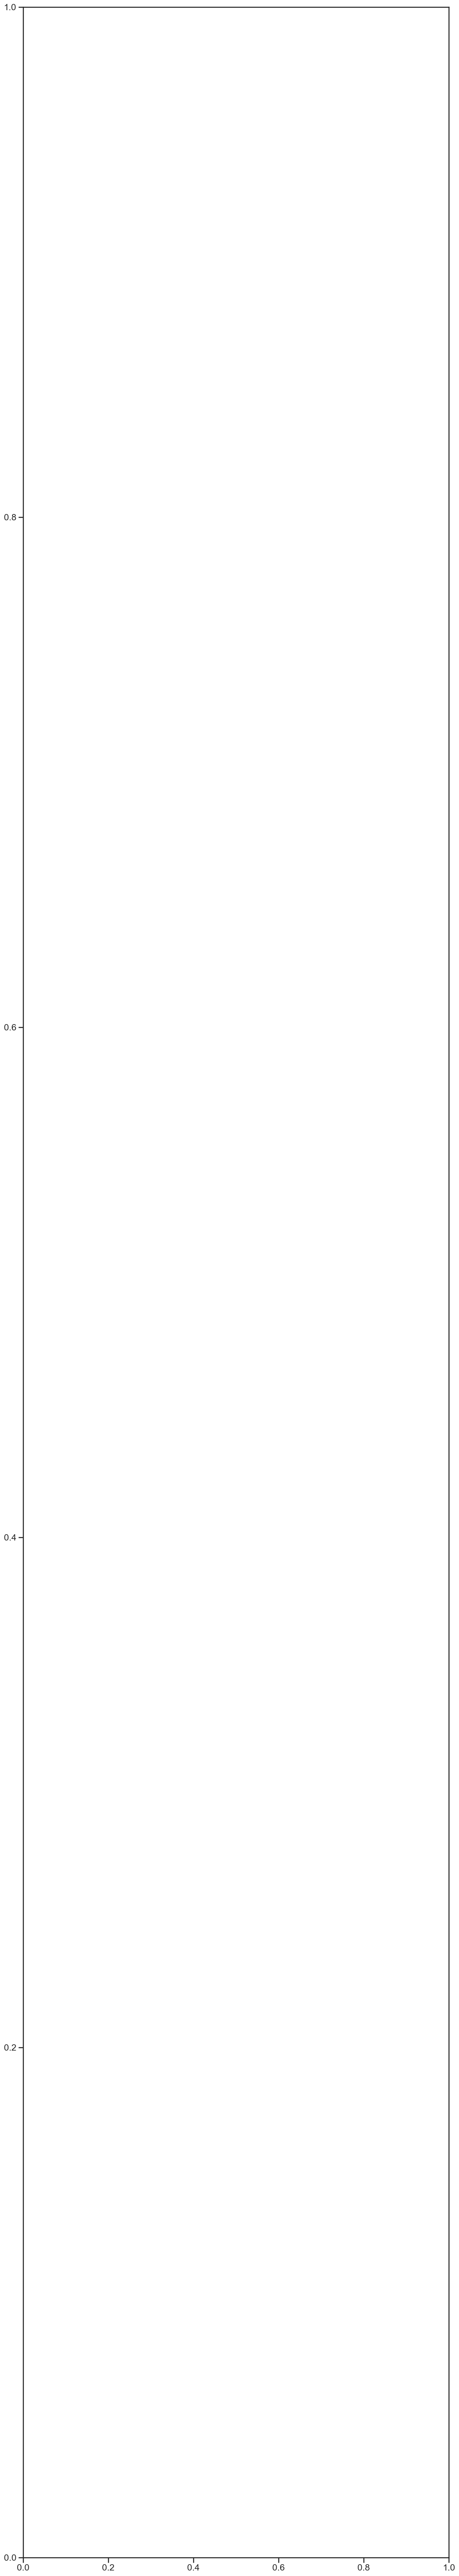

In [26]:
fig, ax = plt.subplots(figsize= (14, max(6, len(rows) * 0.35)))

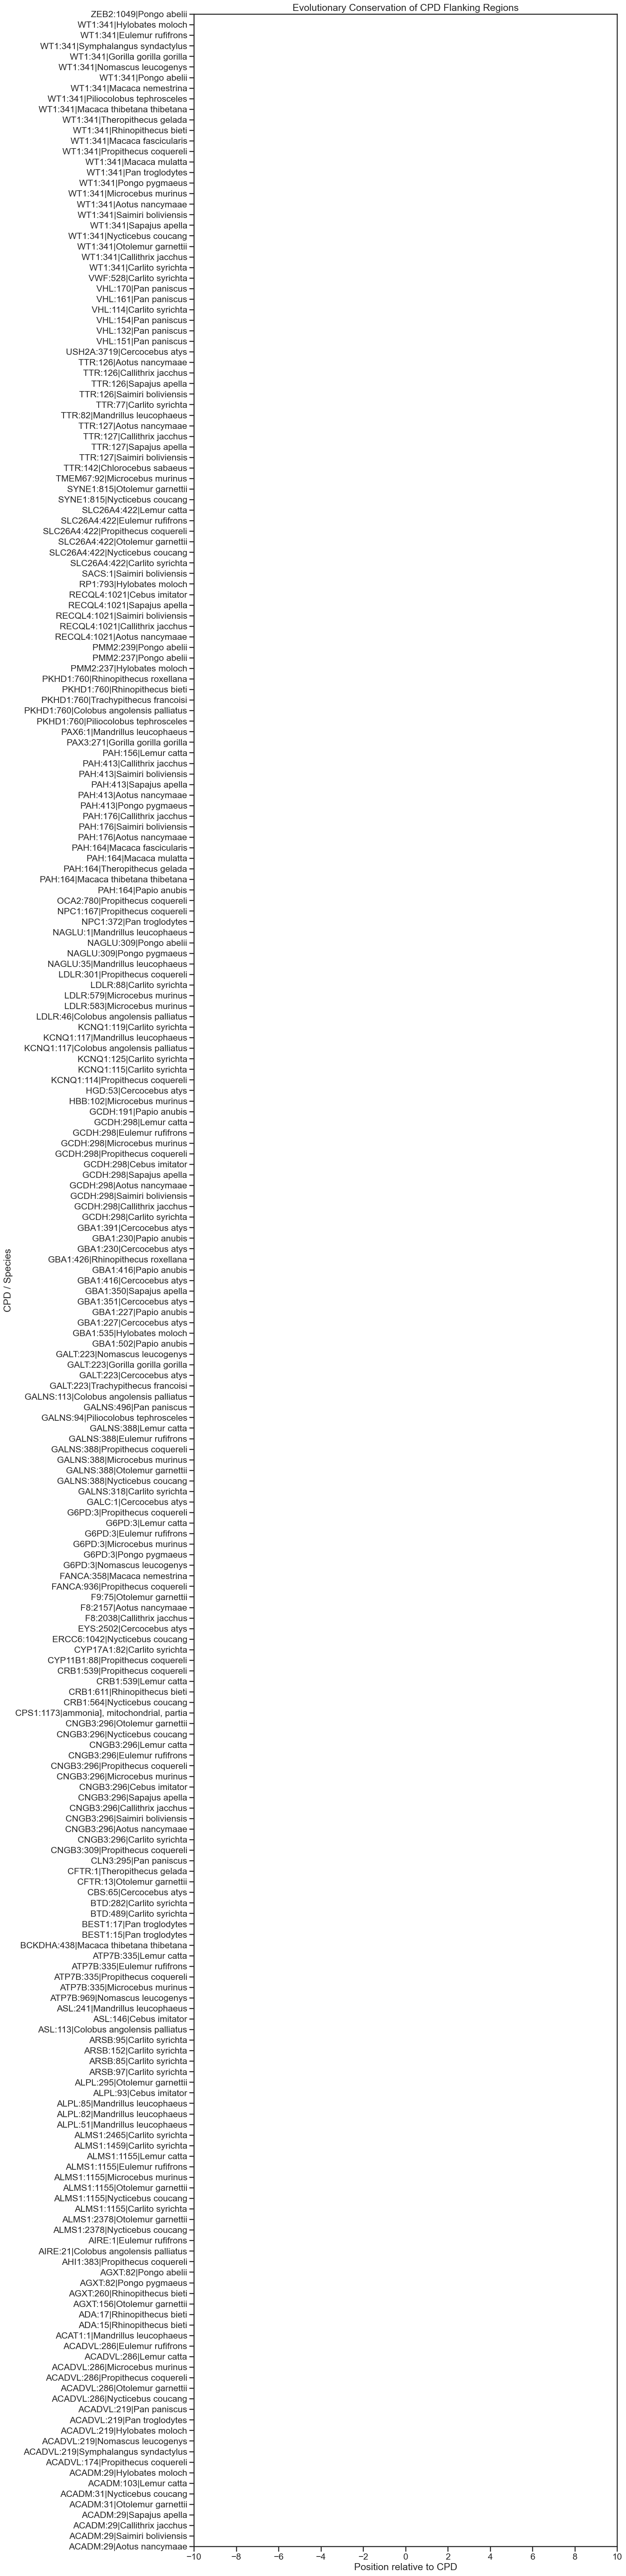

In [ ]:
rows = flanking_df["identifier"].unique()
fig, ax = plt.subplots(figsize= (14, max(6, len(rows) * 0.35)))

for i, cpd in enumerate(rows):
    subset = flanking_df[flanking_df["identifier"] == cpd]

    for _, row in subset.iterrows():
        position = row["relative_position"]
        value = row["plot_value"]

        if pd.isna(value):
            continue
        


'''        # Match
        if value == 1:
            ax.plot(
                position, j,
                marker="s",
                markersize=9,
                linestyle="None"
            )

        # Mismatch
        elif value == 0:
            ax.plot(
                position, j,
                marker="s",
                markersize=9,
                linestyle="None",
                markerfacecolor="none"
            )

        # Gap
        elif value == -1:
            ax.plot(
                position, j,
                marker="x",
                markersize=8,
                linestyle="None"
            )

        # CPD position
        elif value == 9:
            ax.plot(
                position, j,
                marker="s",
                markersize=12,
                linestyle="None"
            )'''

#X-axis
ax.set_xticks(range(-10, 11, 2))
#ax.set_xlim(-11, 11)

# CPD is position 0
'''ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)'''
#Y-axis
ax.set_yticks(range(len(rows)))
ax.set_yticklabels(rows)
ax.set_xlabel("Position relative to CPD")
ax.set_ylabel("CPD / Species")
ax.set_title("Evolutionary Conservation of CPD Flanking Regions"
)
#plt.tight_layout()

plt.show()